### Prueba de analisis de documentos del Corpus

#### Limpieza previa al RAG

Se recorren los **PDF** en `corpus/`, se extrae el texto por página y se aplica una **limpieza ligera** orientada a ingestión RAG: normalización Unicode, eliminación de caracteres invisibles, unión de palabras cortadas por guión al fin de línea (artefacto típico de PDF) y colapso de espacios en blanco (alineado con `regatas_assistant/ingestion.py`). El texto limpio se guarda en **`notebooks auxiliares/corpus_limpio/`** (un `.txt` por documento fuente, con separadores por página). Por cada página se registran **caracteres antes vs después** de la limpieza y **gráficos de barras**. Por **documento completo** (texto limpio agregado) se calcula el **porcentaje de tokens que son stop-words** (lista en inglés desde `regatas_assistant/stopwords_en.txt` + vacías frecuentes en español). Variables en memoria: `documentos_limpios`, `metricas_caracteres_por_pagina`, `metricas_stopwords_por_documento`.

Textos limpios guardados en: /Users/marcelo.luna/Library/CloudStorage/OneDrive-Personal/Diplomaturas/01. Inteligencia Artificial Aplicada/Materias/05. Taller de Trabajo Final/Repositorio/DIIA_trabajo_final/notebooks auxiliares/corpus_limpio



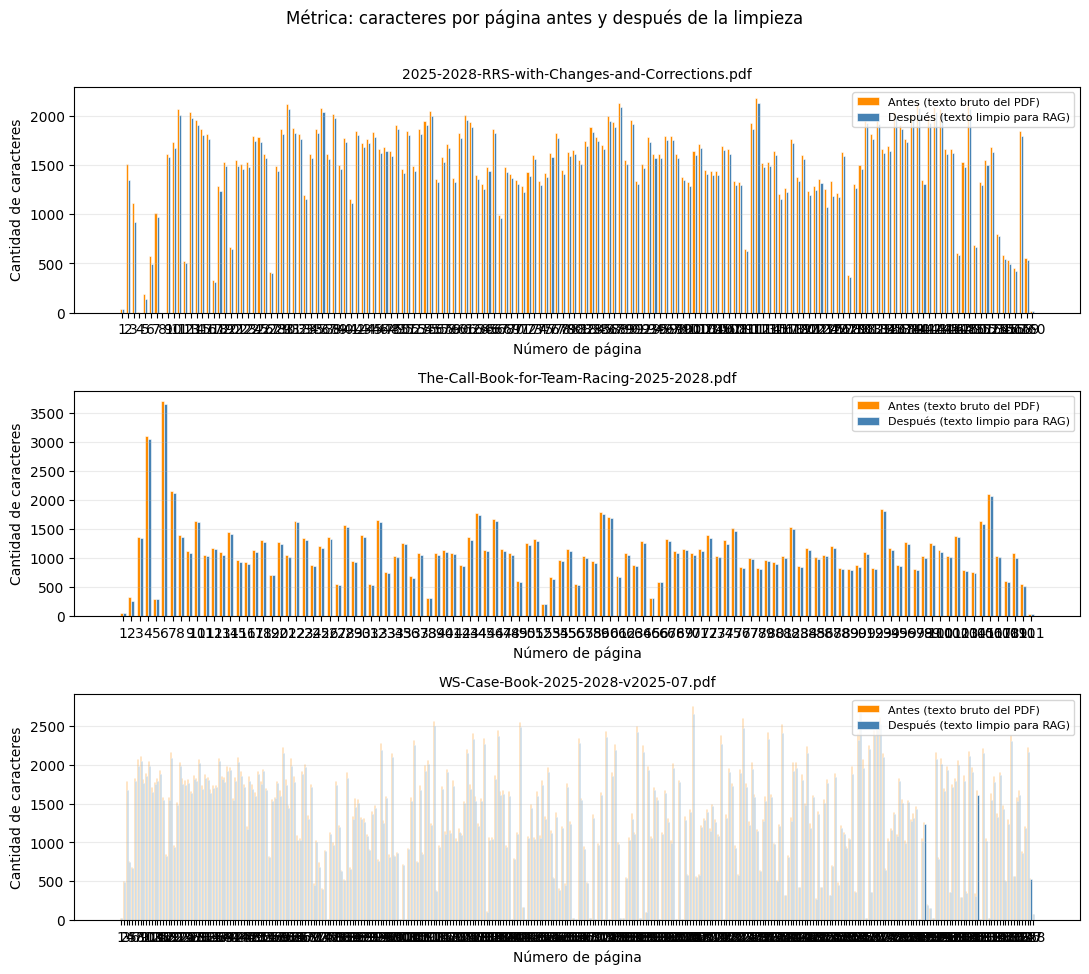

Resumen acumulado por documento (suma de caracteres de todas las páginas):
  2025-2028-RRS-with-Changes-and-Corrections.pdf: antes=240,217 · después=232,902 · delta=-7,315
  The-Call-Book-for-Team-Racing-2025-2028.pdf: antes=124,163 · después=121,053 · delta=-3,110
  WS-Case-Book-2025-2028-v2025-07.pdf: antes=441,165 · después=427,823 · delta=-13,342

Métrica stop-words por documento (texto limpio; lista EN en regatas_assistant/stopwords_en.txt + ES común):
  2025-2028-RRS-with-Changes-and-Corrections.pdf: 48.69% (19,268/39,571 tokens)
  The-Call-Book-for-Team-Racing-2025-2028.pdf: 50.59% (11,210/22,158 tokens)
  WS-Case-Book-2025-2028-v2025-07.pdf: 50.32% (37,716/74,951 tokens)



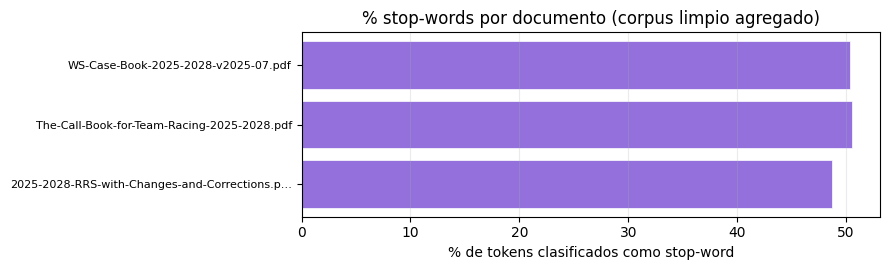

=== 2025-2028-RRS-with-Changes-and-Corrections.pdf — 158 páginas con texto (post-limpieza) ===
  p.1: Racing Rules of Sailing 2025 – 2028
  p.2: N All races in progress are abandoned. Return to the starting area. The warning signal will be made 1 minute after removal unless at that time the race is abandoned again or postponed. RACE SIGNALS The meanings of visual and sound signals are stated below. An arrow pointing up or down (   ) means that a visual signal is displayed or removed. A dot ( • ) means a sound; five short dashes (– – – – …

=== The-Call-Book-for-Team-Racing-2025-2028.pdf — 111 páginas con texto (post-limpieza) ===
  p.1: World Sailing The Call Book For Team Racing 2025 - 2028
  p.2: First edition: July 2001 Eighth edition: April 2025 Contact details for the World Sailing Executive Office Office 401, 4th Floor 3 Shortlands London W6 8DA United Kingdom Telephone: + 44 (0) 20 3940 4888 Email: office@sailing.org © World Sailing Limited All rights reserved

=== WS-Case-Boo

In [3]:
from pathlib import Path

import re

import unicodedata



import matplotlib.pyplot as plt

import numpy as np

from pypdf import PdfReader



# Salida de gráficos dentro de la notebook (Jupyter / VS Code)

%matplotlib inline



# --- Rutas: corpus (entrada) y carpeta de salida junto a esta notebook --------

_cwd = Path.cwd().resolve()



if (_cwd / "corpus").is_dir():

    CORPUS_DIR = _cwd / "corpus"

elif (_cwd.parent / "corpus").is_dir():

    CORPUS_DIR = _cwd.parent / "corpus"

else:

    raise FileNotFoundError(

        "No se encontró corpus/; ejecutá desde la raíz del repo o desde notebooks auxiliares/"

    )





def resolver_notebooks_auxiliares() -> Path:

    """Carpeta notebooks auxiliares/ (donde están las notebooks PoC), sea cual sea el cwd."""

    _marcadores = (

        "PoC (metricas).ipynb",

        "PoC (análisis).ipynb",

        "PoC.ipynb",

    )

    for nb in _marcadores:

        if (_cwd / nb).exists():

            return _cwd

    candidato = _cwd / "notebooks auxiliares"

    for nb in _marcadores:

        if (candidato / nb).exists():

            return candidato

    candidato2 = _cwd.parent / "notebooks auxiliares"

    for nb in _marcadores:

        if (candidato2 / nb).exists():

            return candidato2

    raise FileNotFoundError(

        "No se encontró notebooks auxiliares (PoC metricas/análisis); ejecutá desde la raíz del repo o desde notebooks auxiliares/"

    )





# Documentos limpios persistidos aquí (relativo al repo: notebooks auxiliares/corpus_limpio/)

NOTEBOOKS_AUX = resolver_notebooks_auxiliares()

OUTPUT_LIMPIO = NOTEBOOKS_AUX / "corpus_limpio"

OUTPUT_LIMPIO.mkdir(parents=True, exist_ok=True)





def _repo_root_desde_cwd() -> Path:

    """Raíz del proyecto (donde está la carpeta regatas_assistant/)."""

    c = Path.cwd().resolve()

    if (c / "regatas_assistant").is_dir():

        return c

    if (c.parent / "regatas_assistant").is_dir():

        return c.parent

    raise FileNotFoundError(

        "No se encontró regatas_assistant/; ejecutá desde la raíz del repo o desde notebooks auxiliares/"

    )





REPO_ROOT = _repo_root_desde_cwd()



# Stop-words ES comunes (por si el PDF mezcla español); EN se cargan desde archivo (lista tipo sklearn).

_STOPWORDS_ES = frozenset(

    """

    el la los las lo les un una unos unas uno y e ni o u del al de a en por para con sin sobre entre

    hacia desde hasta durante mediante según tras ante bajo contra dentro fuera ya muy más menos tan

    tanto tanta tantos tantas que cual cuales quien quienes cuyo cuya esto ese esa esos esas aquel

    aquella aquellos aquellas mismo misma mismos mismas otro otra otros otras algún alguna algunos algunas

    """.split()

)





def cargar_stopwords() -> frozenset:

    """Inglés (archivo en el repo) + español; fallback a sklearn si existe."""

    path_en = REPO_ROOT / "regatas_assistant" / "stopwords_en.txt"

    try:

        raw = path_en.read_text(encoding="utf-8")

        en = frozenset(w.lower() for w in raw.split())

    except FileNotFoundError:

        try:

            from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS



            en = frozenset(w.lower() for w in ENGLISH_STOP_WORDS)

        except ImportError:

            en = frozenset(

                "the and of to a in for is on that by with as at from or an be this which it".split()

            )

    return en | _STOPWORDS_ES





STOPWORDS = cargar_stopwords()





def extraer_texto_por_pagina(path_pdf: Path) -> list[tuple[int, str]]:

    """Lee cada página del PDF y devuelve (número de página 1-based, texto bruto)."""

    reader = PdfReader(str(path_pdf))

    paginas: list[tuple[int, str]] = []

    for i, page in enumerate(reader.pages):

        raw = page.extract_text() or ""

        paginas.append((i + 1, raw))

    return paginas





def limpiar_texto_para_rag(texto: str) -> str:

    """

    Limpieza mínima para preparar texto extraído de PDF antes de chunking / RAG.



    - NFKC: unifica caracteres compatibles (ej. variantes tipográficas).

    - Quita espacios de ancho cero / BOM que ensucian tokens y embeddings.

    - Une cortes típicos de PDF: palabra…-\nsiguiente línea → palabras concatenadas.

    - Colapsa espacios como en regatas_assistant.ingestion._read_pdf_pages (regex \\s+).

    """

    t = unicodedata.normalize("NFKC", texto)

    t = re.sub(r"[\u200b-\u200d\ufeff]", "", t)

    # Cortes por guión al final de línea (común en PDF de dos columnas o líneas cortadas)

    t = re.sub(r"-\s*\n\s*", "", t)

    t = re.sub(r"\s+", " ", t)

    return t.strip()





# --- Recorrer PDFs, métricas por página, limpieza, persistencia y gráficos ---------

# Por documento: lista de registros {pagina, caracteres_antes, caracteres_despues}

metricas_caracteres_por_pagina: dict[str, list[dict[str, int]]] = {}

# dict: nombre_archivo -> lista de (página, texto_limpio) solo páginas no vacías tras limpiar

documentos_limpios: dict[str, list[tuple[int, str]]] = {}



for pdf_path in sorted(CORPUS_DIR.glob("*.pdf")):

    filas_metricas: list[dict[str, int]] = []

    paginas_ok: list[tuple[int, str]] = []

    for num_pag, bruto in extraer_texto_por_pagina(pdf_path):

        limpio = limpiar_texto_para_rag(bruto)

        n_antes = len(bruto)

        n_despues = len(limpio)

        # Registramos siempre la página extraída (aunque quede vacía al limpiar)

        filas_metricas.append(

            {

                "pagina": num_pag,

                "caracteres_antes": n_antes,

                "caracteres_despues": n_despues,

            }

        )

        if limpio:

            paginas_ok.append((num_pag, limpio))

    metricas_caracteres_por_pagina[pdf_path.name] = filas_metricas

    documentos_limpios[pdf_path.name] = paginas_ok



    bloques = [f"--- Página {n} ---\n{t}" for n, t in paginas_ok]

    contenido_doc = "\n\n".join(bloques)

    out_path = OUTPUT_LIMPIO / f"{pdf_path.stem}_limpio.txt"

    out_path.write_text(contenido_doc, encoding="utf-8")



print(f"Textos limpios guardados en: {OUTPUT_LIMPIO.resolve()}\n")



# --- Gráficos: caracteres por página (antes vs después de limpiar) --------------

_docs = list(metricas_caracteres_por_pagina.items())

if _docs:

    n_filas = len(_docs)

    fig_h = max(3.5, 3.2 * n_filas)

    fig, axes = plt.subplots(n_filas, 1, figsize=(11, fig_h), sharex=False)

    if n_filas == 1:

        axes = [axes]

    for ax, (nombre_doc, filas) in zip(axes, _docs):

        y_antes = [f["caracteres_antes"] for f in filas]

        y_despues = [f["caracteres_despues"] for f in filas]

        etiquetas_pag = [str(f["pagina"]) for f in filas]

        # Barras verticales agrupadas por página: naranja = antes, azul = después

        x_idx = np.arange(len(filas))

        ancho = 0.36

        ax.bar(

            x_idx - ancho / 2,

            y_antes,

            ancho,

            label="Antes (texto bruto del PDF)",

            color="darkorange",

            edgecolor="white",

            linewidth=0.4,

        )

        ax.bar(

            x_idx + ancho / 2,

            y_despues,

            ancho,

            label="Después (texto limpio para RAG)",

            color="steelblue",

            edgecolor="white",

            linewidth=0.4,

        )

        ax.set_title(nombre_doc, fontsize=10)

        ax.set_xlabel("Número de página")

        ax.set_ylabel("Cantidad de caracteres")

        ax.set_xticks(x_idx, etiquetas_pag)

        ax.legend(loc="upper right", fontsize=8)

        ax.grid(True, axis="y", alpha=0.25)

    fig.suptitle(

        "Métrica: caracteres por página antes y después de la limpieza",

        fontsize=12,

        y=1.01,

    )

    plt.tight_layout()

    plt.show()

else:

    print("No hay PDFs en corpus/; no se generan gráficos.")



# Tabla resumen (totales por documento: suma de caracteres)

print("Resumen acumulado por documento (suma de caracteres de todas las páginas):")

for nombre, filas in metricas_caracteres_por_pagina.items():

    t_antes = sum(f["caracteres_antes"] for f in filas)

    t_despues = sum(f["caracteres_despues"] for f in filas)

    print(f"  {nombre}: antes={t_antes:,} · después={t_despues:,} · delta={t_despues - t_antes:+,}")

print()



# --- Métrica: % de tokens stop-word por documento (texto limpio agregado) -------

# Token = secuencias alfabéticas (inglés / español); stop = pertenece a STOPWORDS.





def tokens_y_pct_stopwords(texto: str, stopwords: frozenset) -> tuple[int, int, float]:

    toks = re.findall(r"[A-Za-záéíóúñÁÉÍÓÚÑ]+", texto.lower())

    n = len(toks)

    if n == 0:

        return 0, 0, 0.0

    n_sw = sum(1 for t in toks if t in stopwords)

    return n, n_sw, 100.0 * n_sw / n





metricas_stopwords_por_documento: dict[str, dict[str, float | int]] = {}

for nombre, paginas in documentos_limpios.items():

    texto_doc = "\n".join(txt for _, txt in paginas)

    n_tok, n_sw, pct = tokens_y_pct_stopwords(texto_doc, STOPWORDS)

    metricas_stopwords_por_documento[nombre] = {

        "tokens": n_tok,

        "tokens_stopword": n_sw,

        "pct_stopwords": round(pct, 2),

    }



print(

    "Métrica stop-words por documento (texto limpio; lista EN en regatas_assistant/stopwords_en.txt + ES común):"

)

for nombre, m in metricas_stopwords_por_documento.items():

    print(

        f"  {nombre}: {m['pct_stopwords']:.2f}% "

        f"({m['tokens_stopword']:,}/{m['tokens']:,} tokens)"

    )

print()



if metricas_stopwords_por_documento:

    fig_sw, ax_sw = plt.subplots(

        figsize=(9, max(2.8, 0.55 * len(metricas_stopwords_por_documento)))

    )

    items_sw = list(metricas_stopwords_por_documento.items())

    nombres_sw = [n[:44] + "…" if len(n) > 44 else n for n, _ in items_sw]

    pcts_sw = [m["pct_stopwords"] for _, m in items_sw]

    y_sw = np.arange(len(items_sw))

    ax_sw.barh(y_sw, pcts_sw, color="mediumpurple", edgecolor="white", linewidth=0.5)

    ax_sw.set_yticks(y_sw, nombres_sw, fontsize=8)

    ax_sw.set_xlabel("% de tokens clasificados como stop-word")

    ax_sw.set_title("% stop-words por documento (corpus limpio agregado)")

    ax_sw.grid(True, axis="x", alpha=0.25)

    plt.tight_layout()

    plt.show()



# Vista rápida del texto limpio (primeras páginas con contenido)

for nombre, paginas in documentos_limpios.items():

    print(f"=== {nombre} — {len(paginas)} páginas con texto (post-limpieza) ===")

    for num_pag, txt in paginas[:2]:

        preview = txt[:400] + ("…" if len(txt) > 400 else "")

        print(f"  p.{num_pag}: {preview}")

    print()

